Background dataset has 120 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=120 when initializing the masker.


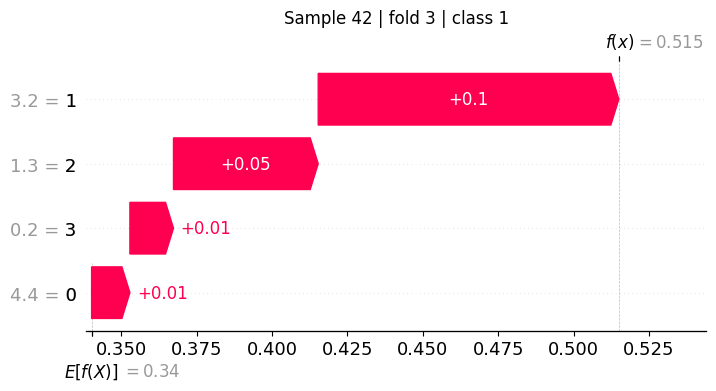

Background dataset has 120 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=120 when initializing the masker.


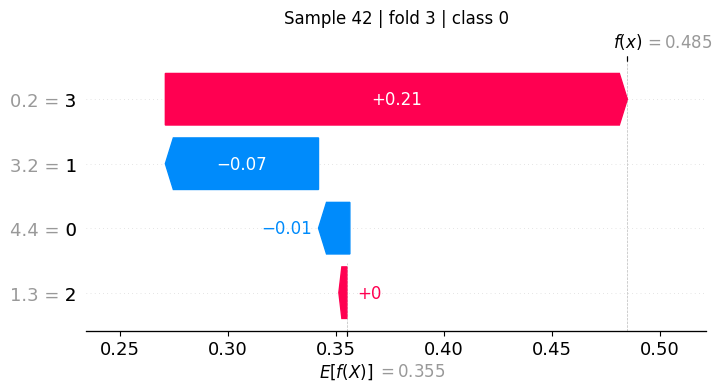

sample_idx: 42
original: 0
observed noisy: 0
predicted by filter: 1
predicted-class top_k: []
original-class top_k: []


(ClassificationFilterSHAPReport(items=[ClassificationFilterSHAPExplanation(sample_idx=42, fold_idx=3, true_label_idx=0, true_label=0, oof_pred_idx=1, oof_pred=1, target_class_idx=0, target_class=0, confidence=0.485, noise_score=0.3695820274309886, is_noisy=True, base_value=0.35505, shap_values=array([-0.01452917, -0.0709625 ,  0.00139583,  0.21404583]), top_k=[], figure=None)], sample_indices=array([42]), noisy_indices=array([42]), noisy_only=False, sort_by='confidence', ascending=True, class_index=np.int64(0), top_k=None, algorithm='auto', background_size=None, background_random_state=None, max_evals=None, max_display=10, return_figures=False, show_figures=True, feature_names=array([0, 1, 2, 3], dtype=object), n_samples=150, n_features=4, cv=5, random_state=0, estimator_name='RandomForestClassifier'),
 ClassificationFilterSHAPReport(items=[ClassificationFilterSHAPExplanation(sample_idx=42, fold_idx=3, true_label_idx=0, true_label=0, oof_pred_idx=1, oof_pred=1, target_class_idx=1, targ

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from filters import ClassificationFilter, explain_classification_filter_noisy_instances

X, y = load_iris(return_X_y=True)
classes = np.unique(y)

def inject_noise(y, frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    y_clean = y.copy()
    y_noisy = y_clean.copy()

    n_noise = max(1, int(round(frac * len(y_clean))))
    noise_idx = rng.choice(len(y_clean), size=n_noise, replace=False)

    for idx in noise_idx:
        alternatives = classes[classes != y_noisy[idx]]
        y_noisy[idx] = rng.choice(alternatives)

    return y_clean, y_noisy

for seed in range(50):
    y_clean, y_noisy = inject_noise(y, frac=0.1, seed=seed)

    flt = ClassificationFilter(
        estimator=RandomForestClassifier(n_estimators=200, random_state=0),
        cv=5,
        action="detect",
        random_state=0,
    )
    flt.fit(X, y_noisy)

    noisy_candidates = np.flatnonzero(flt.noisy_mask_)
    if noisy_candidates.size == 0:
        continue

    pred = np.asarray(flt.result_.oof_pred, dtype=object)
    matching = [i for i in noisy_candidates if y_clean[i] != pred[i]]
    if matching:
        sample_idx = int(matching[0])
        break
else:
    raise RuntimeError("No se encontró una instancia ruidosa adecuada.")

clean_label = y_clean[sample_idx]
observed_label = y_noisy[sample_idx]
pred_label = flt.result_.oof_pred[sample_idx]

assert observed_label != pred_label

report_pred = explain_classification_filter_noisy_instances(
    flt,
    sample_indices=[sample_idx],
    noisy_only=False,
    class_index="predicted",
    top_k=None,
    show_figures=True,
    return_figures=False,
)

report_clean = explain_classification_filter_noisy_instances(
    flt,
    sample_indices=[sample_idx],
    noisy_only=False,
    class_index=clean_label,
    top_k=None,
    show_figures=True,
    return_figures=False,
)

print("sample_idx:", sample_idx)
print("original:", clean_label)
print("observed noisy:", observed_label)
print("predicted by filter:", pred_label)
print("predicted-class top_k:", report_pred[0].top_k)
print("original-class top_k:", report_clean[0].top_k)
report_clean, report_pred

NameError: name 'report_clean' is not defined